In [8]:
# ============================================================
#  Assignment 4 — Common Setup
#  每個組員在自己的 section 前先跑這整塊
# ============================================================

# ---------- 安裝 ----------
!pip install openml scikit-image torch torchvision -q

# ---------- Imports ----------
import os, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import warnings
warnings.filterwarnings("ignore")

# ---------- 全域設定 ----------
RANDOM_SEED  = 2026
DATASET_ID   = 44238
IMG_SIZE_CNN = 128   # SmallCNN 用
IMG_SIZE_RES = 224   # ResNet / ViT 用

# ---------- 資料載入 ----------
print("Downloading Meta-Album PLK Micro...")
dataset = openml.datasets.get_dataset(
    DATASET_ID,
    download_data=True,
    download_all_files=True,
)
print("Dataset name :", dataset.name)

X_meta, y_meta, _, attr_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format="dataframe",
)
print("Columns      :", list(X_meta.columns))
print("Samples      :", len(X_meta))
print("Classes      :", y_meta.nunique())

# ---------- 建立 df_images ----------
# 找出 cache 目錄下所有圖片
# dataset.data_file 對圖片資料集為 None，改用 OpenML cache 目錄
cache_dir = Path(openml.config.get_cache_directory()) / "datasets" / str(DATASET_ID)
all_images = (
    list(cache_dir.rglob("*.jpg"))
    + list(cache_dir.rglob("*.png"))
    + list(cache_dir.rglob("*.jpeg"))
)
print(f"Image files found: {len(all_images)}")
assert len(all_images) == 800, f"Expected 800 images, got {len(all_images)}"

# 用 OpenML metadata 取得 authoritative filename→label，避免依賴目錄結構
path_by_stem = {p.stem: str(p) for p in all_images}
records = []
for fname, label in zip(X_meta["FILE_NAME"], y_meta):
    stem = Path(fname).stem
    if stem in path_by_stem:
        records.append({"path": path_by_stem[stem], "label": str(label)})
assert len(records) == 800, f"Matched {len(records)}/800 images to metadata"

df_images = pd.DataFrame(records)
print("\nClass distribution:")
print(df_images["label"].value_counts().sort_index().to_string())

# ---------- Label Encoding ----------
le = LabelEncoder()
df_images["label_enc"] = le.fit_transform(df_images["label"])
NUM_CLASSES = len(le.classes_)
print(f"\nNum classes : {NUM_CLASSES}")
print(f"Classes     : {list(le.classes_)}")

# ---------- 60 / 20 / 20 Stratified Split ----------
train_df, temp_df = train_test_split(
    df_images,
    test_size=0.40,
    stratify=df_images["label"],
    random_state=RANDOM_SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
assert (train_df["label"].value_counts() == 24).all(), "train split mismatch"
assert (val_df["label"].value_counts()   ==  8).all(), "val split mismatch"
assert (test_df["label"].value_counts()  ==  8).all(), "test split mismatch"
print("Split check passed ✓")

# ---------- 通用圖片載入（Classical ML 用）----------
def load_image_flat(path, size=(128, 128), grayscale=True):
    """載入單張圖片，回傳 flatten 的 float32 array，pixel 值 /255"""
    mode = "L" if grayscale else "RGB"
    img  = Image.open(path).convert(mode).resize(size)
    return np.asarray(img, dtype=np.float32).flatten() / 255.0


def make_pixel_features(df, size=(128, 128), grayscale=True):
    """整批 df 轉成 pixel feature matrix"""
    features = np.stack([
        load_image_flat(row["path"], size, grayscale)
        for _, row in df.iterrows()
    ])
    labels = le.transform(df["label"].values)
    return features, labels


# ---------- PyTorch Dataset ----------
class PlanktonDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["path"]).convert("RGB")
        label = int(row["label_enc"])
        if self.transform:
            img = self.transform(img)
        return img, label


# ---------- Transforms ----------
# CNN（從頭訓練）
cnn_train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
cnn_eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CNN, IMG_SIZE_CNN)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ResNet18 / ViT（ImageNet 正規化）
resnet_train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_RES, IMG_SIZE_RES)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
resnet_eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_RES, IMG_SIZE_RES)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ---------- 通用 DataLoader 工廠 ----------
def make_loaders(train_tf, eval_tf, batch_train=32, batch_eval=64):
    train_ds = PlanktonDataset(train_df, transform=train_tf)
    val_ds   = PlanktonDataset(val_df,   transform=eval_tf)
    test_ds  = PlanktonDataset(test_df,  transform=eval_tf)
    return (
        DataLoader(train_ds, batch_size=batch_train, shuffle=True,  num_workers=0, pin_memory=True),
        DataLoader(val_ds,   batch_size=batch_eval,  shuffle=False, num_workers=0, pin_memory=True),
        DataLoader(test_ds,  batch_size=batch_eval,  shuffle=False, num_workers=0, pin_memory=True),
    )

# ---------- Device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")

# ---------- 通用 evaluate 函數（PyTorch）----------
def evaluate(model, loader, criterion):
    """回傳 (avg_loss, accuracy, macro_f1, all_preds, all_labels)"""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for x, y_batch in loader:
            x, y_batch = x.to(device), y_batch.to(device)
            logits = model(x)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, macro_f1, all_preds, all_labels


# ---------- 通用訓練 Loop ----------
def train_model(model, train_loader, val_loader,
                epochs=20, lr=1e-3, weight_decay=1e-4):
    """
    回傳 history dict：
      {"train_loss", "val_loss", "train_acc", "val_acc"}
    以及訓練秒數。
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    history = {"train_loss": [], "val_loss": [],
               "train_acc": [],  "val_acc": []}
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        for x, y_batch in train_loader:
            x, y_batch = x.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y_batch)
            loss.backward()
            optimizer.step()

        tr_loss, tr_acc, _, _, _ = evaluate(model, train_loader, criterion)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader,   criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        print(f"Epoch {epoch:02d}/{epochs}  "
              f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
              f"train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}")

    elapsed = time.time() - t0
    print(f"Training time: {elapsed:.1f}s  ({elapsed/60:.1f} min)")
    return history, elapsed


# ---------- Learning Curve 畫圖 ----------
def plot_learning_curves(history, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"],   label="Val")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"],   label="Val")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.show()


# ---------- Confusion Matrix ----------
def plot_cm(y_true, y_pred, model_name="Model"):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, colorbar=False, xticks_rotation=90)
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


# ============================================================
#  以下各組員貼上自己的模型定義 + 呼叫 train_model / evaluate
#
#  組員1（Model A / B）：直接用 make_pixel_features()
#                       或 make_hog_features() 接 sklearn
#
#  組員2（Model C / D）：呼叫 make_loaders(cnn_train_tf, cnn_eval_tf)
#                       或 make_loaders(resnet_train_tf, resnet_eval_tf)
#                       再呼叫 train_model(model, ...) + plot_learning_curves(...)
#
#  組員3（Model E / F）：同上，替換 model 為 ViT/DeiT
# ============================================================


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


Dataset name : Meta_Album_PLK_Micro
Columns      : ['FILE_NAME', 'SUPER_CATEGORY']
Samples      : 800
Classes      : 20
Image files found: 800

Class distribution:
label
Chaetoceros                   40
Chrysochromulina              40
Dinophysis                    40
Emiliania_huxleyi             40
Ephemera                      40
Leptocylindrus                40
Mesodinium_sp                 40
Prorocentrum                  40
Pseudochattonella_farcimen    40
Pseudonitzschia               40
Rhizosolenia                  40
Skeletonema                   40
Strombidium_inclinatum        40
Strombidium_oculatum          40
Strombidium_wulffi            40
Thalassiosira_dirty           40
Tintinnid                     40
diatom_flagellate             40
kiteflagellates               40
pennates_on_diatoms           40

Num classes : 20
Classes     : ['Chaetoceros', 'Chrysochromulina', 'Dinophysis', 'Emiliania_huxleyi', 'Ephemera', 'Leptocylindrus', 'Mesodinium_sp', 'Prorocentrum', 'Pse

## ✅ 驗證用範例模型 A — Raw Pixels + Logistic Regression

Building pixel features...
Train: (480, 16384)  Val: (160, 16384)  Test: (160, 16384)

=== Model A: Raw Pixels + LR  (96.7s) ===
Val  Acc=0.4437  F1=0.4190
Test Acc=0.4188  F1=0.4102


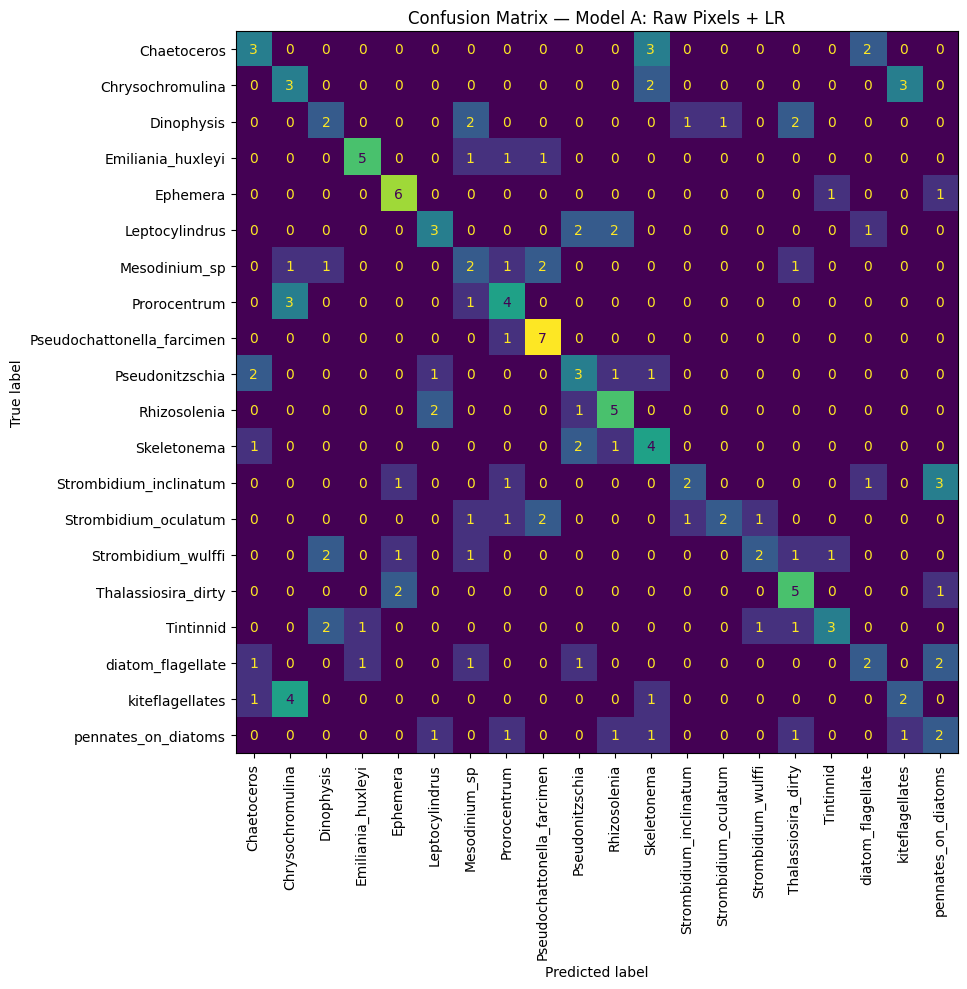

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Building pixel features...")
X_train_raw, y_train_enc = make_pixel_features(train_df)
X_val_raw,   y_val_enc   = make_pixel_features(val_df)
X_test_raw,  y_test_enc  = make_pixel_features(test_df)
print(f"Train: {X_train_raw.shape}  Val: {X_val_raw.shape}  Test: {X_test_raw.shape}")

t0 = time.time()
model_a = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_SEED, C=0.1)),
])
model_a.fit(X_train_raw, y_train_enc)
elapsed_a = time.time() - t0

pred_val  = model_a.predict(X_val_raw)
pred_test = model_a.predict(X_test_raw)
print(f"\n=== Model A: Raw Pixels + LR  ({elapsed_a:.1f}s) ===")
print(f"Val  Acc={accuracy_score(y_val_enc, pred_val):.4f}  F1={f1_score(y_val_enc, pred_val, average='macro', zero_division=0):.4f}")
print(f"Test Acc={accuracy_score(y_test_enc, pred_test):.4f}  F1={f1_score(y_test_enc, pred_test, average='macro', zero_division=0):.4f}")

plot_cm(y_test_enc, pred_test, "Model A: Raw Pixels + LR")

## ✅ 驗證用範例模型 C — SmallCNN（確認 PyTorch pipeline 正常）

In [10]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        return self.classifier(torch.flatten(self.features(x), 1))

# DataLoader
train_loader, val_loader, test_loader = make_loaders(cnn_train_tf, cnn_eval_tf)

# 計算 trainable params
cnn_model = SmallCNN(num_classes=NUM_CLASSES).to(device)
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"SmallCNN trainable params: {trainable_params:,}")

SmallCNN trainable params: 95,828


In [11]:
# 先跑 3 個 epoch 確認 pipeline 正常（完整跑再改 epochs=30）
history_cnn, elapsed_cnn = train_model(
    cnn_model, train_loader, val_loader,
    epochs=3, lr=1e-3, weight_decay=1e-4,
)
print(f"\nPipeline check passed ✓  ({elapsed_cnn:.1f}s for 3 epochs)")

Epoch 01/3  train_loss=2.9750  val_loss=2.9754  train_acc=0.0604  val_acc=0.1062
Epoch 02/3  train_loss=2.8960  val_loss=2.8865  train_acc=0.0750  val_acc=0.0875
Epoch 03/3  train_loss=2.8348  val_loss=2.8106  train_acc=0.0958  val_acc=0.1313
Training time: 5.9s  (0.1 min)

Pipeline check passed ✓  (5.9s for 3 epochs)


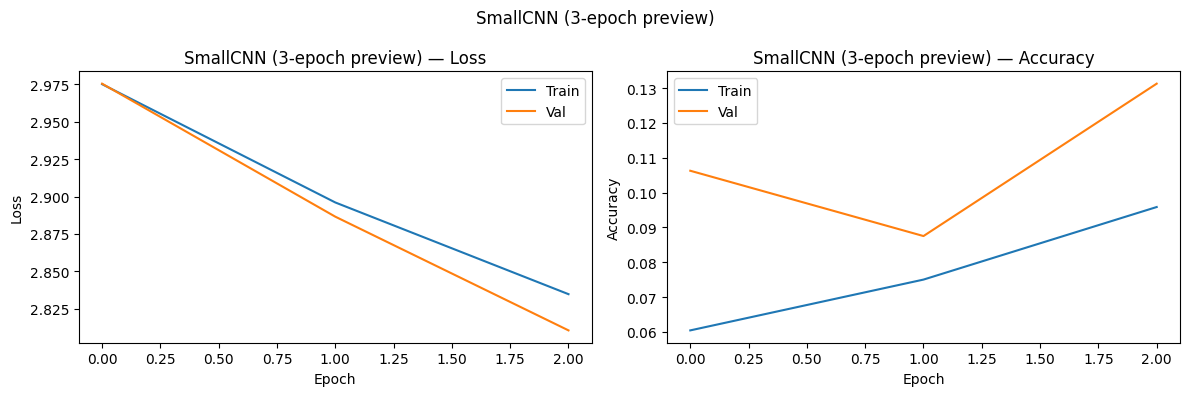

In [12]:
plot_learning_curves(history_cnn, "SmallCNN (3-epoch preview)")

Test Acc=0.1437  Macro-F1=0.0545


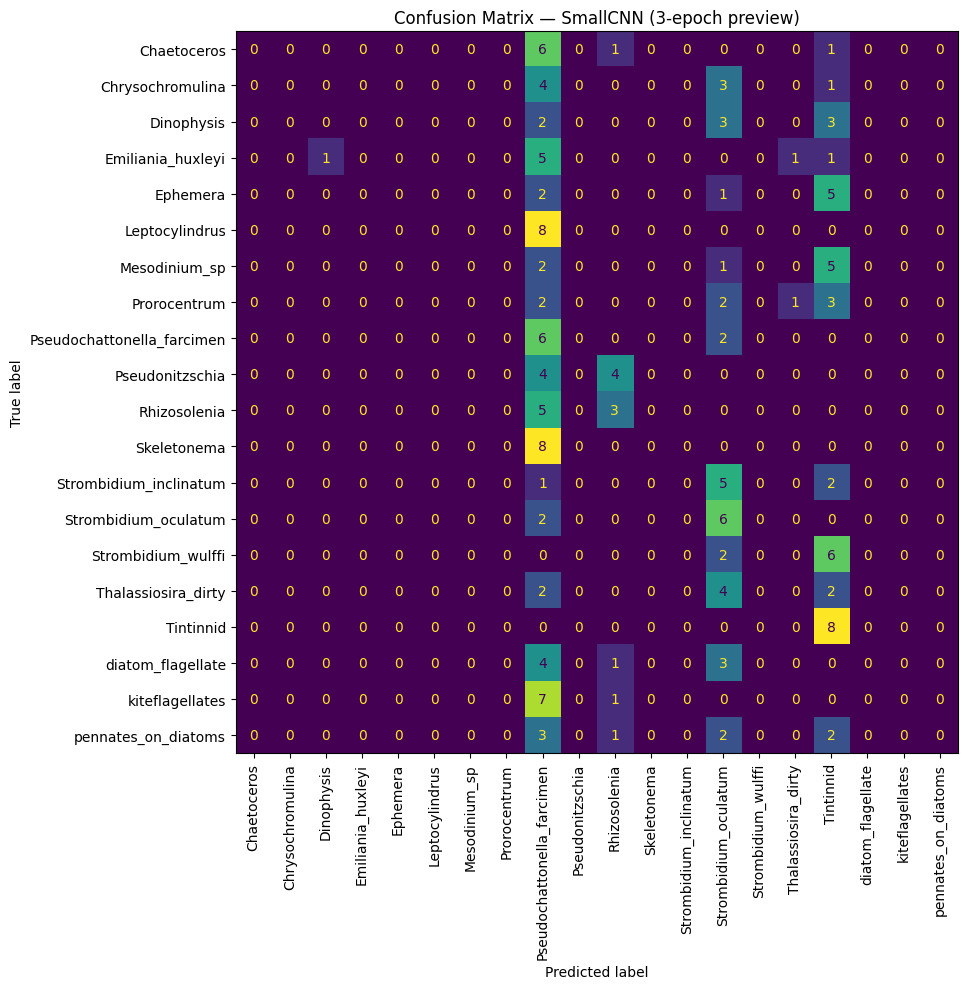

In [13]:
criterion = nn.CrossEntropyLoss()
_, test_acc, test_f1, preds, labels = evaluate(cnn_model, test_loader, criterion)
print(f"Test Acc={test_acc:.4f}  Macro-F1={test_f1:.4f}")
plot_cm(labels, preds, "SmallCNN (3-epoch preview)")